# Prueba local: pipeline sin acceso a malla (eje/plano por triangulacion multivista)

Notebook de prueba **local**, sin GPU (Molmo2-8B no entra en la VRAM disponible
de este equipo -- ver celda de setup). Implementa y valida, sobre **un objeto
axial y uno planar**, el pipeline descrito en `docs/pipeline_sin_malla.md`:

```
1. Renderizado multivista                    [ya hecho, reusado]
2. Pointing con Molmo2 (1, 6, 14, 26 vistas) [reusado: axial y planar traidos del servidor]
3.1 Inferencia de eje, SIN malla              [NUEVO -- implementado abajo]
3.2 Inferencia de plano, SIN malla            [NUEVO -- implementado abajo]
4. Consolidacion                              [fuera de alcance de esta prueba -- ver nota mas abajo]
5. Mapeo a la malla SOLO para validar         [reusa Mapping/evaluate.py]
```

**Insumo usado por cada etapa:**
- Puntos 2D de Molmo2 (`molmo_multiview*.json`, ya generado, con predicciones
  para 4 grupos de vistas: `VIEW_GROUPS = [1, 6, 14, 26]`).
- Parametros de camara por vista ($R$, $T$, FoV) -- vienen incluidos en el
  propio JSON (`images_sent[i]["R"/"T"]`), no hace falta `metadata_all.json`
  aparte.
- La malla `.obj` y el `.txt` de ground truth -- usados **unicamente** en la
  etapa 5 (validacion), nunca en 3.1/3.2.

**Nota sobre el alcance**: esta prueba valida el caso de **un solo plano**
sobre **un objeto de cada tipo**, barriendo prompts y n_views -- es una
prueba de concepto de la geometria, no una validacion estadistica sobre el
dataset completo. La extension a 2-3 planos (S4 del documento) y la corrida
sobre el dataset completo quedan para el pipeline en el servidor.

## 0. Setup: rutas, imports, y estado del entorno local

In [1]:
import sys
import json
from pathlib import Path
from itertools import combinations

import numpy as np

# --- Rutas ---------------------------------------------------------------
REPO_ROOT    = Path(r"C:\Users\HP\Desktop\Seminario de Tesis I\Symmetry-Detection-Using-Multimodal-Vision-Language-Models")
DATA_ROOT    = Path(r"C:\Users\HP\Desktop\Seminario de Tesis I\data")
OBJECTS_ROOT = DATA_ROOT / "objects"
RENDERS_ROOT = DATA_ROOT / "renders"

sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "Mapping"))

from pipeline_common.camera import molmo_to_ndc, build_camera_rays, cast_ray
from pipeline_common.datasets import load_mesh, OBJECTS_SUBDIR
import evaluate as ev   # Mapping/evaluate.py -- parse_true_label, angular_error_deg, SDE, etc.

FOV_DEG = 60.0
IMAGE_SIZE = 224

# Grupos de n_views a barrer -- coincide con DEFAULT_VIEW_GROUPS[:4] de
# MolmoPointing/molmo_multiview_runner.py; todos los JSON de prompt usados en
# este notebook traen predicciones para estas 4 configuraciones.
VIEW_GROUPS = [1, 6, 14, 26]

print("REPO_ROOT   :", REPO_ROOT, REPO_ROOT.exists())
print("OBJECTS_ROOT:", OBJECTS_ROOT, OBJECTS_ROOT.exists())
print("RENDERS_ROOT:", RENDERS_ROOT, RENDERS_ROOT.exists())
print("DATA_ROOT   :", DATA_ROOT, DATA_ROOT.exists())
print("VIEW_GROUPS :", VIEW_GROUPS)

REPO_ROOT   : C:\Users\HP\Desktop\Seminario de Tesis I\Symmetry-Detection-Using-Multimodal-Vision-Language-Models True
OBJECTS_ROOT: C:\Users\HP\Desktop\Seminario de Tesis I\data\objects True
RENDERS_ROOT: C:\Users\HP\Desktop\Seminario de Tesis I\data\renders True
DATA_ROOT   : C:\Users\HP\Desktop\Seminario de Tesis I\data True
VIEW_GROUPS : [1, 6, 14, 26]


**Nota sobre Molmo2 local**: este equipo tiene GPU (RTX 3050, 6GB VRAM) pero
`transformers` no esta instalado y, mas importante, Molmo2-8B no entra en
6GB de VRAM (necesita ~16GB+ en bf16). Por eso:

- Para el **objeto axial**, reusamos predicciones de Molmo2 **reales**, ya
  generadas (probablemente en el servidor) y presentes localmente en
  `data/renders/axis_sym/<id>/224/flat/molmo_multiview.json`.
- Para el **objeto planar**, se trajo del servidor un objeto de muestra
  completo (`data/plane_sample/<id>/224/flat/`, con renders, manifest y
  predicciones ya generadas para varios prompts) -- ver seccion 2.

## 1. Objeto axial: cargar mesh, ground truth, y barrido de prompt x n_views disponibles

Usamos `10433e5bd8fa2a337b00c7b93209c459` (carpeta `data/axis_sample/`), que trae
predicciones reales de Molmo2 para 12 variantes de prompt (`axis_v00`..`axis_v05`,
con y sin sufijo `_1`) mas Flow B y Flow C sobre `axis_v05_1` -- 14 prompts en
total, cada uno con predicciones para `VIEW_GROUPS = [1, 6, 14, 26]`, todas
generadas **despues** del fix de `get_n_views_entries` (ver diagnostico de
vistas mas abajo), a diferencia del objeto usado originalmente en esta prueba
(`1a9c1cbf1ca9ca24274623f5a5d0bcdc`, en `data/renders/axis_sym/...`), cuyo
unico JSON de 6 vistas resulto ser anterior a ese fix.

In [2]:
AXIS_OBJECT_ID = "10433e5bd8fa2a337b00c7b93209c459"

axis_obj_path   = OBJECTS_ROOT / OBJECTS_SUBDIR["axis_sym"] / f"{AXIS_OBJECT_ID}.obj"
axis_txt_path   = OBJECTS_ROOT / OBJECTS_SUBDIR["axis_sym"] / f"{AXIS_OBJECT_ID}.txt"
AXIS_SAMPLE_DIR = DATA_ROOT / "axis_sample" / AXIS_OBJECT_ID / "224" / "flat"

assert axis_obj_path.exists(), f"No se encontro la malla: {axis_obj_path}"
assert axis_txt_path.exists(), f"No se encontro el GT: {axis_txt_path}"
assert AXIS_SAMPLE_DIR.exists(), f"No se encontro la carpeta de muestras: {AXIS_SAMPLE_DIR}"

axis_mesh = load_mesh(axis_obj_path)
axis_gt   = ev.parse_true_label(axis_txt_path)

print("Malla axial :", axis_mesh.vertices.shape[0], "vertices")
print("GT axial    :", axis_gt)
print()

# Todas las corridas de prompt disponibles para este objeto -- cada archivo
# molmo_multiview_axis_<id>.json trae predicciones para varios n_views.
axis_json_paths = sorted(AXIS_SAMPLE_DIR.glob("molmo_multiview_axis_*.json"))
print(f"JSONs de prompt encontrados ({len(axis_json_paths)}):")

axis_runs = {}   # (label, n_views) -> dict de esa config de n_views
for path in axis_json_paths:
    label = path.stem.replace("molmo_multiview_", "")
    with open(path, encoding="utf-8") as f:
        all_groups = json.load(f)
    found = []
    for n_views in VIEW_GROUPS:
        key = str(n_views)
        if key in all_groups:
            axis_runs[(label, n_views)] = all_groups[key]
            found.append(n_views)
    print(f"  {label:22s} n_views disponibles: {found}")

print(f"\nTotal de corridas cargadas (prompt x n_views): {len(axis_runs)}")


Malla axial : 520 vertices
GT axial    : {'type': 'axis', 'elements': [{'direction': [0.757178333282068, 0.641083315310224, 0.12527232112099473], 'origin': [0.0, 0.0, 0.0]}]}

JSONs de prompt encontrados (14):
  axis_v00               n_views disponibles: [1, 6, 14, 26]
  axis_v00_1             n_views disponibles: [1, 6, 14, 26]
  axis_v01               n_views disponibles: [1, 6, 14, 26]
  axis_v01_1             n_views disponibles: [1, 6, 14, 26]
  axis_v02               n_views disponibles: [1, 6, 14, 26]
  axis_v02_1             n_views disponibles: [1, 6, 14, 26]
  axis_v03               n_views disponibles: [1, 6, 14, 26]
  axis_v03_1             n_views disponibles: [1, 6, 14, 26]
  axis_v04               n_views disponibles: [1, 6, 14, 26]
  axis_v04_1             n_views disponibles: [1, 6, 14, 26]
  axis_v05               n_views disponibles: [1, 6, 14, 26]
  axis_v05_1             n_views disponibles: [1, 6, 14, 26]
  axis_v05_1_flowB       n_views disponibles: [1, 6, 14, 2

### Diagnostico de la configuracion de vistas

`docs/pipeline_sin_malla.md` S3.1 ("Riesgo conocido") advierte que la
triangulacion de lineas es mal condicionada cuando los centros de camara son
casi coplanares/colineales. `MolmoPointing/molmo_multiview_runner.py`
(`get_n_views_entries`) documenta explicitamente el caso degenerado a
evitar: tomar "las primeras N entradas" de la secuencia Fibonacci concentra
las camaras cerca de un polo (p.ej. elevacion +66 a +90 grados para
n_views=6).

**Hallazgo confirmado (no solo especulacion)**: el JSON usado originalmente en
esta prueba (`data/renders/axis_sym/1a9c1cbf1ca9ca24274623f5a5d0bcdc/224/flat/molmo_multiview.json`)
resulto tener exactamente ese bug -- sus 6 vistas usaban los indices Fibonacci
`[0, 1, 2, 3, 4, 5]` (elevacion 65-89 grados, todas cerca del polo norte), en vez
de los `[0, 23, 45, 68, 90, 113]` que produce el `get_n_views_entries` actual
(`linspace` sobre el indice). El archivo se genero el 2026-05-27, **antes** del
commit `a6ffeac` (2026-06-16) que introdujo el fix -- es un artefacto de datos
viejo, no un bug del codigo actual.

Los JSONs de `data/axis_sample/10433e5bd8fa2a337b00c7b93209c459/` (usados desde
ahora en esta prueba) se generaron despues de ese fix. Verificamos esto
explicitamente para las 14 x 4 = 56 corridas cargadas arriba, comparando los
`index` de `images_sent` contra lo que produce `get_n_views_entries` hoy **para
cada n_views por separado** (el conjunto de indices esperado es distinto para
cada tamano de grupo) -- en vez de solo inspeccionar visualmente el rango de
elevacion.

In [3]:
def expected_indices_for(n_views, total=114):
    if n_views >= total:
        return list(range(total))
    return sorted({int(round(i)) for i in np.linspace(0, total - 1, n_views)})

print("Indices esperados (get_n_views_entries) por n_views:")
for n in VIEW_GROUPS:
    idxs = expected_indices_for(n)
    preview = idxs if len(idxs) <= 8 else f"{idxs[:4]} ... {idxs[-4:]} ({len(idxs)} en total)"
    print(f"  n_views={n:3d}: {preview}")
print()

all_ok = True
by_nviews_summary = {n: {"ok": 0, "total": 0} for n in VIEW_GROUPS}
for (label, n_views), data in sorted(axis_runs.items(), key=lambda kv: (kv[0][1], kv[0][0])):
    sent_indices = sorted(cam["index"] for cam in data["images_sent"])
    elevations   = [cam["elevation"] for cam in data["images_sent"]]
    expected     = expected_indices_for(n_views)
    ok = sent_indices == expected
    all_ok &= ok
    by_nviews_summary[n_views]["total"] += 1
    by_nviews_summary[n_views]["ok"]    += int(ok)
    status = "OK" if ok else "DESFASADO"
    print(f"  {label:22s} n_views={n_views:3d}  n_sent={len(sent_indices):3d}  "
          f"elev=[{min(elevations):+4.0f}, {max(elevations):+4.0f}]  [{status}]")
    if not ok:
        print(f"      esperado={expected}")
        print(f"      obtenido={sent_indices}")

print()
print("Resumen por n_views:")
for n in VIEW_GROUPS:
    s = by_nviews_summary[n]
    print(f"  n_views={n:3d}: {s['ok']}/{s['total']} corridas OK")

print()
if all_ok:
    print("Todas las corridas usan las vistas esperadas para su n_views -- "
          "sin riesgo del caso degenerado documentado.")
else:
    print("[atencion] Al menos una corrida usa vistas distintas a las esperadas -- "
          "revisar su fecha de generacion antes de confiar en su resultado.")


Indices esperados (get_n_views_entries) por n_views:
  n_views=  1: [0]
  n_views=  6: [0, 23, 45, 68, 90, 113]
  n_views= 14: [0, 9, 17, 26] ... [87, 96, 104, 113] (14 en total)
  n_views= 26: [0, 5, 9, 14] ... [99, 104, 108, 113] (26 en total)

  axis_v00               n_views=  1  n_sent=  1  elev=[ +89,  +89]  [OK]
  axis_v00_1             n_views=  1  n_sent=  1  elev=[ +89,  +89]  [OK]
  axis_v01               n_views=  1  n_sent=  1  elev=[ +89,  +89]  [OK]
  axis_v01_1             n_views=  1  n_sent=  1  elev=[ +89,  +89]  [OK]
  axis_v02               n_views=  1  n_sent=  1  elev=[ +89,  +89]  [OK]
  axis_v02_1             n_views=  1  n_sent=  1  elev=[ +89,  +89]  [OK]
  axis_v03               n_views=  1  n_sent=  1  elev=[ +89,  +89]  [OK]
  axis_v03_1             n_views=  1  n_sent=  1  elev=[ +89,  +89]  [OK]
  axis_v04               n_views=  1  n_sent=  1  elev=[ +89,  +89]  [OK]
  axis_v04_1             n_views=  1  n_sent=  1  elev=[ +89,  +89]  [OK]
  axis_v05   

### Ejemplo de un prompt: mostrar el prompt exacto enviado y la salida cruda de Molmo2

Solo a modo ilustrativo se muestra una corrida (`axis_v01_1`, n_views=6); el
barrido completo sobre las 14 x 4 corridas se hace en la seccion 3.1.

In [4]:
EXAMPLE_LABEL   = "axis_v01_1"
EXAMPLE_N_VIEWS = 6

print("=" * 70)
print(f"PROMPT ENVIADO A MOLMO2 (axial, n_views={EXAMPLE_N_VIEWS}, prompt={EXAMPLE_LABEL}):")
print("=" * 70)
print(axis_runs[(EXAMPLE_LABEL, EXAMPLE_N_VIEWS)]["prompt_used"])
print()
print("=" * 70)
print("SALIDA CRUDA DE MOLMO2:")
print("=" * 70)
print(axis_runs[(EXAMPLE_LABEL, EXAMPLE_N_VIEWS)]["raw_output"])


PROMPT ENVIADO A MOLMO2 (axial, n_views=6, prompt=axis_v01_1):
You are given multiple views of the SAME 3D object.

The object has ONE dominant axis of rotational symmetry.

For each image, find ONE pair of bilaterally symmetric points: two surface points equidistant from and on opposite sides of the global symmetry axis.

For each image:
1. Identify the projected symmetry axis for that view.
2. Return:
   - obj_id 1: a point on the LEFT side of the object,
   - obj_id 2: its exact mirror on the RIGHT side (same height, equidistant from the axis).

The midpoint between each pair lies on the projected axis.

IMPORTANT RULES:
- Within each image, the two points MUST be at approximately the same height.
- The midpoint between each pair MUST be at the horizontal center of the object at that height — equidistant from both silhouette edges.
- Use the SAME global axis consistently across all views.
- Across DIFFERENT views, choose DIFFERENT heights for the bilateral pair — prefer upper height

## 2. Objeto planar: cargar mesh, ground truth y barrido de todos los prompts x n_views disponibles

Se trajo del servidor la carpeta completa de un objeto planar (renders +
manifest + predicciones para varios prompts), extraida localmente en
`data/plane_sample/<object_id>/224/flat/` -- **un nivel mas superficial**
que la convencion `renders/<symmetry_type>/<object_id>/...` usada en el
resto del repo (no hay subcarpeta `plane_sym` intermedia). El `.obj`/`.txt`
de la malla y el ground truth se siguen leyendo de `OBJECTS_ROOT`, igual
que para el objeto axial.

**Igual que con el eje, cargamos TODOS los prompts disponibles** (`plane_v00`
.. `plane_v05`, con y sin sufijo `_1`, mas Flow B/C sobre `plane_v04_1` -- 14
en total), cada uno con predicciones para `VIEW_GROUPS = [1, 6, 14, 26]` --
56 corridas de prompt x n_views. Antes solo se usaba `plane_v01_1` (elegido
a mano por ser un prompt bilateral real, ver nota mas abajo); ahora se barren
todos para responder empiricamente si **algun** prompt/n_views logra F1_ref
> 0, en vez de asumir de antemano cual prompt es mejor.

**Nota sobre `plane_v04_1`** (el prompt "default" del pipeline original):
es del tipo *silhouette-midpoint* (pide el punto medio horizontal en dos
alturas), y en la practica Molmo2 devuelve casi siempre `x=500` (centro
exacto de la imagen) para ambos puntos -- el plano de interpretacion
resultante es SIEMPRE vertical, asi que la triangulacion colapsa
trivialmente al eje vertical del mundo en vez de dar una linea distinta por
vista. Esto es exactamente el problema que `docs/pipeline_sin_malla.md` S6
ya anticipaba: v04 esta pensado para el pipeline CON malla (donde el
ray-casting ancla el punto a la superficie real), no para triangulacion
pura. Se incluye igual en el barrido para confirmar esto empiricamente en
vez de solo citarlo.

In [5]:
PLANE_OBJECT_ID = "10654ea604644c8eca7ed590d69b9804"
PLANE_SAMPLE_DIR = DATA_ROOT / "plane_sample" / PLANE_OBJECT_ID / "224" / "flat"

plane_ready = False

plane_obj_path = OBJECTS_ROOT / OBJECTS_SUBDIR["plane_sym"] / f"{PLANE_OBJECT_ID}.obj"
plane_txt_path = OBJECTS_ROOT / OBJECTS_SUBDIR["plane_sym"] / f"{PLANE_OBJECT_ID}.txt"

missing = [p for p in (plane_obj_path, plane_txt_path) if not p.exists()]
if missing:
    print("[falta] No se encontraron estos archivos todavia:")
    for p in missing:
        print("   -", p)
else:
    plane_mesh = load_mesh(plane_obj_path)
    plane_gt = ev.parse_true_label(plane_txt_path)
    print("Malla planar        :", plane_mesh.vertices.shape[0], "vertices")
    print("GT planar           :", plane_gt)
    print(f"Planos GT (.txt)    : {len(plane_gt['elements'])}  "
          f"-- clave para saber si un error alto es por matchear el plano equivocado "
          f"o si genuinamente no hay mas planos con los que confundirse (ver seccion 4).")
    print()

    # Todas las corridas de prompt disponibles para este objeto -- cada archivo
    # molmo_multiview_plane_<id>.json trae predicciones para varios n_views.
    plane_json_paths = sorted(PLANE_SAMPLE_DIR.glob("molmo_multiview_plane_*.json"))
    print(f"JSONs de prompt encontrados ({len(plane_json_paths)}):")

    plane_runs = {}   # (label, n_views) -> dict de esa config de n_views
    for path in plane_json_paths:
        label = path.stem.replace("molmo_multiview_", "")
        with open(path, encoding="utf-8") as f:
            all_groups = json.load(f)
        found = []
        for n_views in VIEW_GROUPS:
            key = str(n_views)
            if key in all_groups:
                plane_runs[(label, n_views)] = all_groups[key]
                found.append(n_views)
        print(f"  {label:22s} n_views disponibles: {found}")

    plane_ready = len(plane_runs) > 0
    print(f"\nTotal de corridas cargadas (prompt x n_views): {len(plane_runs)}")

    EXAMPLE_LABEL_PLANE   = "plane_v01_1"
    EXAMPLE_N_VIEWS_PLANE = 6
    print()
    print(f"PROMPT ENVIADO A MOLMO2 (planar, n_views={EXAMPLE_N_VIEWS_PLANE}, prompt={EXAMPLE_LABEL_PLANE}):")
    print(plane_runs[(EXAMPLE_LABEL_PLANE, EXAMPLE_N_VIEWS_PLANE)]["prompt_used"][:500], "...")
    print()
    print("SALIDA CRUDA DE MOLMO2:")
    print(plane_runs[(EXAMPLE_LABEL_PLANE, EXAMPLE_N_VIEWS_PLANE)]["raw_output"])


Malla planar        : 1416 vertices
GT planar           : {'type': 'plane', 'elements': [{'normal': [0.9999982096749206, 0.0015400770679094174, 0.0010994587660698098], 'origin': [-0.0, 0.0, 0.0]}]}
Planos GT (.txt)    : 1  -- clave para saber si un error alto es por matchear el plano equivocado o si genuinamente no hay mas planos con los que confundirse (ver seccion 4).

JSONs de prompt encontrados (14):
  plane_v00              n_views disponibles: [1, 6, 14, 26]
  plane_v00_1            n_views disponibles: [1, 6, 14, 26]
  plane_v01              n_views disponibles: [1, 6, 14, 26]
  plane_v01_1            n_views disponibles: [1, 6, 14, 26]
  plane_v02              n_views disponibles: [1, 6, 14, 26]
  plane_v02_1            n_views disponibles: [1, 6, 14, 26]
  plane_v03              n_views disponibles: [1, 6, 14, 26]
  plane_v03_1            n_views disponibles: [1, 6, 14, 26]
  plane_v04              n_views disponibles: [1, 6, 14, 26]
  plane_v04_1            n_views disponible

## 3. Utilidades geometricas comunes (sin malla)

Implementan la maquinaria de `docs/pipeline_sin_malla.md` S3.1/S3.2:
- `ray_dir_for_point`: rayo de camara mundial para un punto Molmo2 (reusa
  `pipeline_common.camera`).
- `interpretation_plane_normal`: normal del "plano de interpretacion" que
  contiene el centro de camara y dos rayos (p.ej. los puntos top/bottom de
  una vista).
- `triangulate_line`: interseccion (minimos cuadrados) de >=2 planos de
  interpretacion -> linea 3D (direccion + punto), la misma maquinaria
  para el eje axial y para las "lineas dentro del plano" del caso planar.

In [6]:
def ray_dir_for_point(x, y, R, T, fov_deg=FOV_DEG):
    # Origen (centro de camara) y direccion de rayo mundial para un punto Molmo2 (x, y).
    ndc_x, ndc_y = molmo_to_ndc(x, y)
    origin, direction = build_camera_rays(ndc_x, ndc_y, R, T, fov_deg, IMAGE_SIZE)
    return origin, direction


def view_forward_direction(R, T, fov_deg=FOV_DEG):
    # Direccion de vista (eje principal de la camara) en coordenadas mundiales.
    _, direction = build_camera_rays(0.0, 0.0, R, T, fov_deg, IMAGE_SIZE)
    return direction


def interpretation_plane_normal(dir_a, dir_b):
    # Normal del plano que contiene el centro de camara y dos rayos que parten de el.
    n = np.cross(dir_a, dir_b)
    norm = np.linalg.norm(n)
    if norm < 1e-9:
        return None
    return n / norm


def triangulate_line(camera_centers, plane_normals):
    # Intersecta >=2 planos de interpretacion (cada uno: normal n_i, pasa por
    # el centro de camara C_i) para recuperar una linea 3D (Bartoli & Sturm 2005).
    #   - Direccion: vector nulo comun de los n_i (SVD).
    #   - Punto sobre la linea: resuelve n_i . p = n_i . C_i por minimos cuadrados.
    N = np.asarray(plane_normals, dtype=np.float64)   # (k, 3)
    C = np.asarray(camera_centers, dtype=np.float64)  # (k, 3)

    _, _, Vt = np.linalg.svd(N)
    direction = Vt[-1]
    direction /= np.linalg.norm(direction)

    b = np.einsum("ij,ij->i", N, C)
    point, *_ = np.linalg.lstsq(N, b, rcond=None)

    return point, direction


def get_point_by_obj_id(pts, obj_id):
    return next((p for p in pts if p["obj_id"] == obj_id), None)

## 3.1 Simetria axial, sin malla

Por cada vista con 2 puntos (top=obj_id 1, bottom=obj_id 2), arma el plano de
interpretacion de esa vista; con >=2 vistas, triangula la linea 3D del eje.

Corremos esto sobre las 14 x 4 = 56 corridas de `axis_runs` (prompt x n_views,
todas con vistas bien distribuidas, confirmado arriba) para comparar como
cambia el error angular segun el prompt Y segun cuantas vistas se usan.

In [7]:
def estimate_axis_no_mesh(points_by_image, images_sent, fov_deg=FOV_DEG):
    centers, normals = [], []
    for img_idx_str, pts in points_by_image.items():
        p_top = get_point_by_obj_id(pts, 1)
        p_bot = get_point_by_obj_id(pts, 2)
        if p_top is None or p_bot is None:
            continue
        cam = images_sent[int(img_idx_str)]
        C, d_top = ray_dir_for_point(p_top["x"], p_top["y"], cam["R"], cam["T"], fov_deg)
        _, d_bot = ray_dir_for_point(p_bot["x"], p_bot["y"], cam["R"], cam["T"], fov_deg)
        n = interpretation_plane_normal(d_top, d_bot)
        if n is None:
            continue
        centers.append(C)
        normals.append(n)

    if len(normals) < 2:
        raise ValueError(f"Se necesitan >=2 vistas validas; se obtuvieron {len(normals)}.")

    point, direction = triangulate_line(centers, normals)
    return {"direction": direction.tolist(), "origin": point.tolist(), "n_views_used": len(normals)}


axis_pred_new_by_key = {}   # (label, n_views) -> prediccion
axis_skipped_new = []
for (label, n_views), data in axis_runs.items():
    try:
        axis_pred_new_by_key[(label, n_views)] = estimate_axis_no_mesh(data["points_by_image"], data["images_sent"])
    except ValueError as e:
        axis_skipped_new.append((label, n_views, str(e)))

print(f"{len(axis_pred_new_by_key)}/{len(axis_runs)} corridas produjeron una estimacion de eje (SIN malla).")
if axis_skipped_new:
    print("Omitidas:")
    for label, n_views, msg in sorted(axis_skipped_new, key=lambda t: (t[1], t[0])):
        print(f"  {label:22s} n_views={n_views:3d}: {msg}")


37/56 corridas produjeron una estimacion de eje (SIN malla).
Omitidas:
  axis_v00               n_views=  1: Se necesitan >=2 vistas validas; se obtuvieron 1.
  axis_v00_1             n_views=  1: Se necesitan >=2 vistas validas; se obtuvieron 1.
  axis_v01               n_views=  1: Se necesitan >=2 vistas validas; se obtuvieron 1.
  axis_v01_1             n_views=  1: Se necesitan >=2 vistas validas; se obtuvieron 1.
  axis_v02               n_views=  1: Se necesitan >=2 vistas validas; se obtuvieron 1.
  axis_v02_1             n_views=  1: Se necesitan >=2 vistas validas; se obtuvieron 1.
  axis_v03               n_views=  1: Se necesitan >=2 vistas validas; se obtuvieron 1.
  axis_v03_1             n_views=  1: Se necesitan >=2 vistas validas; se obtuvieron 1.
  axis_v04               n_views=  1: Se necesitan >=2 vistas validas; se obtuvieron 1.
  axis_v04_1             n_views=  1: Se necesitan >=2 vistas validas; se obtuvieron 1.
  axis_v05               n_views=  1: Se necesita

### Comparacion con el metodo actual (ray-casting contra la malla + SVD)

Solo para contraste en este notebook -- reusa `pipeline_common.camera.cast_ray`
(que si necesita la malla) y ajusta el eje por SVD sobre los puntos 3D
resultantes, igual que `Mapping/estimate_symmetry.py`. Tambien corrido sobre
las 14 x 4 corridas de prompt x n_views para comparar contra el metodo sin
malla en igualdad de condiciones.

In [8]:
def estimate_axis_old_raycast(points_by_image, images_sent, mesh, fov_deg=FOV_DEG):
    pts3d = []
    for img_idx_str, pts in points_by_image.items():
        cam = images_sent[int(img_idx_str)]
        for p in pts:
            ndc_x, ndc_y = molmo_to_ndc(p["x"], p["y"])
            origin, direction = build_camera_rays(ndc_x, ndc_y, cam["R"], cam["T"], fov_deg, IMAGE_SIZE)
            hit = cast_ray(mesh, origin, direction)
            if hit["hit"]:
                pts3d.append(hit["point_3d"])

    pts3d = np.asarray(pts3d, dtype=np.float64)
    if len(pts3d) < 2:
        raise ValueError("Muy pocos puntos 3D con hit en la malla.")

    centroid = pts3d.mean(axis=0)
    _, _, Vt = np.linalg.svd(pts3d - centroid)
    direction = Vt[0]  # primera componente principal = direccion del eje
    return {"direction": direction.tolist(), "origin": centroid.tolist(), "n_points": len(pts3d)}


axis_pred_old_by_key = {}   # (label, n_views) -> prediccion
axis_skipped_old = []
for (label, n_views), data in axis_runs.items():
    try:
        axis_pred_old_by_key[(label, n_views)] = estimate_axis_old_raycast(
            data["points_by_image"], data["images_sent"], axis_mesh
        )
    except ValueError as e:
        axis_skipped_old.append((label, n_views, str(e)))

print(f"{len(axis_pred_old_by_key)}/{len(axis_runs)} corridas produjeron una estimacion de eje (CON malla).")
if axis_skipped_old:
    print("Omitidas:")
    for label, n_views, msg in sorted(axis_skipped_old, key=lambda t: (t[1], t[0])):
        print(f"  {label:22s} n_views={n_views:3d}: {msg}")


50/56 corridas produjeron una estimacion de eje (CON malla).
Omitidas:
  axis_v00               n_views=  1: Muy pocos puntos 3D con hit en la malla.
  axis_v01               n_views=  1: Muy pocos puntos 3D con hit en la malla.
  axis_v01_1             n_views=  1: Muy pocos puntos 3D con hit en la malla.
  axis_v02               n_views=  1: Muy pocos puntos 3D con hit en la malla.
  axis_v03               n_views=  1: Muy pocos puntos 3D con hit en la malla.
  axis_v03_1             n_views=  1: Muy pocos puntos 3D con hit en la malla.


## 3.2 Simetria planar, sin malla (esquema iterativo)

Implementa el algoritmo de `docs/pipeline_sin_malla.md` S3.2:

1. Por cada **par** de vistas, triangula una linea 3D candidata (misma
   maquinaria de 3.1) -- se asume que, si ambas vistas estan "de canto"
   al plano real, esa linea vive dentro del plano de simetria.
2. Combina pares de lineas (de vistas distintas) por producto cruzado
   -> normales candidatas para el plano.
3. Puntua cada candidata por que tan "de canto" (angulo cercano a 90 grados,
   es decir |cos(theta)| chico) estan las vistas respecto a ella -- **sin
   malla**, solo con la pose de camara ya conocida.
4. Se queda con las vistas "de canto" respecto a la mejor candidata y
   reajusta la normal por minimos cuadrados (SVD) sobre las lineas
   recuperadas solo con esas vistas.

Se muestra aca un solo prompt (`plane_v01_1`) a modo ilustrativo, con
`verbose=True` para ver el mecanismo paso a paso -- el barrido completo sobre
los 14 prompts x 4 n_views (56 combinaciones) se hace en la seccion 4, que
ademas itera este mismo algoritmo para buscar mas de un plano por corrida.

In [9]:
def line_from_view_pair(view_i, view_j, points_by_image, images_sent, fov_deg=FOV_DEG):
    centers, normals = [], []
    for idx in (view_i, view_j):
        pts = points_by_image.get(str(idx), [])
        p1 = get_point_by_obj_id(pts, 1)
        p2 = get_point_by_obj_id(pts, 2)
        if p1 is None or p2 is None:
            return None
        cam = images_sent[idx]
        C, d1 = ray_dir_for_point(p1["x"], p1["y"], cam["R"], cam["T"], fov_deg)
        _, d2 = ray_dir_for_point(p2["x"], p2["y"], cam["R"], cam["T"], fov_deg)
        n = interpretation_plane_normal(d1, d2)
        if n is None:
            return None
        centers.append(C)
        normals.append(n)
    point, direction = triangulate_line(centers, normals)
    return point, direction


def estimate_plane_no_mesh(points_by_image, images_sent, fov_deg=FOV_DEG, edge_on_thresh=0.5, verbose=True):
    view_idxs = sorted(
        int(k) for k, pts in points_by_image.items()
        if get_point_by_obj_id(pts, 1) is not None and get_point_by_obj_id(pts, 2) is not None
    )
    if len(view_idxs) < 4:
        raise ValueError(f"Se necesitan >=4 vistas validas (2 pares independientes); hay {len(view_idxs)}.")

    # 1. una linea candidata por cada par de vistas
    pair_lines = []
    for i, j in combinations(view_idxs, 2):
        res = line_from_view_pair(i, j, points_by_image, images_sent, fov_deg)
        if res is not None:
            point, direction = res
            pair_lines.append(((i, j), point, direction))

    if len(pair_lines) < 2:
        raise ValueError("No hay suficientes pares de lineas para generar candidatos de plano.")

    # direccion de vista por indice (para puntuar de canto / de frente)
    view_dirs = {
        idx: view_forward_direction(images_sent[idx]["R"], images_sent[idx]["T"], fov_deg)
        for idx in view_idxs
    }

    def score_normal(n):
        vals = sorted(abs(np.dot(view_dirs[i], n)) for i in view_idxs)
        k = max(2, len(vals) // 2)   # mitad mas favorable, robusto a outliers
        return float(np.mean(vals[:k]))

    # 2. normales candidatas: producto cruzado entre pares de lineas de vistas distintas
    candidates = []
    for a in range(len(pair_lines)):
        pa, _, dir_a = pair_lines[a]
        for b in range(a + 1, len(pair_lines)):
            pb, _, dir_b = pair_lines[b]
            if set(pa) & set(pb):
                continue  # exigir vistas distintas para independencia
            n = np.cross(dir_a, dir_b)
            norm = np.linalg.norm(n)
            if norm < 1e-6:
                continue
            candidates.append(n / norm)

    if not candidates:
        raise ValueError("No se pudieron generar normales candidatas (lineas casi paralelas).")

    scored = sorted(candidates, key=score_normal)
    best_normal = scored[0]
    if verbose:
        print(f"  candidatos evaluados: {len(candidates)}   mejor score inicial: {score_normal(best_normal):.4f}")

    # 3. vistas "de canto" respecto al mejor candidato
    good_views = [i for i in view_idxs if abs(np.dot(view_dirs[i], best_normal)) < edge_on_thresh]
    if verbose:
        print(f"  vistas 'de canto' seleccionadas: {good_views}  (de {view_idxs})")

    # 4. reajuste: normal = vector nulo (SVD) de las direcciones de linea entre vistas buenas
    refit_dirs   = [d for (pa, _, d) in pair_lines if set(pa).issubset(good_views)]
    refit_points = [p for (pa, p, _) in pair_lines if set(pa).issubset(good_views)]

    if len(refit_dirs) >= 2:
        D = np.asarray(refit_dirs)
        _, _, Vt = np.linalg.svd(D)
        refined_normal = Vt[-1]
        refined_normal /= np.linalg.norm(refined_normal)
        used_points = refit_points
    else:
        if verbose:
            print("  (no hay suficientes lineas dentro del subconjunto 'de canto'; se usa el candidato inicial sin reajuste)")
        refined_normal = best_normal
        used_points = [p for (_, p, _) in pair_lines]

    origin = np.mean(used_points, axis=0)

    return {
        "normal": refined_normal.tolist(),
        "origin": origin.tolist(),
        "n_views_used": len(good_views),
        "n_candidates": len(candidates),
        "good_views": good_views,   # usado por la consolidacion (seccion 4) para reducir el pool
    }


plane_pred_new_by_nviews = {}   # n_views -> prediccion (un solo plano, demo con plane_v01_1)
if plane_ready:
    EXAMPLE_LABEL_PLANE_32 = "plane_v01_1"
    for n_views in VIEW_GROUPS:
        key = (EXAMPLE_LABEL_PLANE_32, n_views)
        if key not in plane_runs:
            continue
        data = plane_runs[key]
        print(f"--- n_views={n_views} (prompt={EXAMPLE_LABEL_PLANE_32}) ---")
        try:
            pred = estimate_plane_no_mesh(data["points_by_image"], data["images_sent"], verbose=True)
            plane_pred_new_by_nviews[n_views] = pred
            print(f"  normal: {np.round(pred['normal'], 4)}   origen: {np.round(pred['origin'], 4)}")
        except ValueError as e:
            print(f"  [omitido] {e}")
        print()
    print(f"{len(plane_pred_new_by_nviews)}/{len(VIEW_GROUPS)} grupos de n_views produjeron una estimacion de plano "
          f"(SIN malla, prompt={EXAMPLE_LABEL_PLANE_32}). El barrido completo sobre todos los prompts esta en la seccion 4.")
else:
    print("[omitido] Trae las predicciones planares del servidor (celda de la seccion 2) antes de correr esto.")

--- n_views=1 (prompt=plane_v01_1) ---
  [omitido] Se necesitan >=4 vistas validas (2 pares independientes); hay 1.

--- n_views=6 (prompt=plane_v01_1) ---
  candidatos evaluados: 3   mejor score inicial: 0.1535
  vistas 'de canto' seleccionadas: [1, 3, 4]  (de [0, 1, 2, 3, 4, 5])
  (no hay suficientes lineas dentro del subconjunto 'de canto'; se usa el candidato inicial sin reajuste)
  normal: [ 0.104  -0.7579 -0.6441]   origen: [-0.0088  0.0805  0.1093]

--- n_views=14 (prompt=plane_v01_1) ---
  candidatos evaluados: 3003   mejor score inicial: 0.1017
  vistas 'de canto' seleccionadas: [0, 1, 2, 3, 4, 5, 6, 13]  (de [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13])
  normal: [0.3967 0.7402 0.5429]   origen: [ 0.0212  0.1079 -0.1226]

--- n_views=26 (prompt=plane_v01_1) ---


  candidatos evaluados: 44850   mejor score inicial: 0.1399
  vistas 'de canto' seleccionadas: [2, 3, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 18, 19, 22, 23]  (de [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25])
  normal: [ 0.0707  0.9733 -0.2183]   origen: [-0.0289 -0.1722  0.0506]

3/4 grupos de n_views produjeron una estimacion de plano (SIN malla, prompt=plane_v01_1). El barrido completo sobre todos los prompts esta en la seccion 4.


### Comparacion con el metodo actual (ray-casting contra la malla + SVD) -- version planar

Analoga a la comparacion ya hecha para el eje (seccion 3.1): ray-casting de
cada punto 2D de Molmo2 contra la malla real, luego SVD sobre la nube de
puntos 3D resultante -- pero para el plano la normal es la componente de
**minima** varianza (`Vt[-1]`), no la de maxima varianza como en el eje,
exactamente igual que `Mapping/estimate_symmetry.py::fit_plane`. Corrido
sobre las mismas 14 x 4 = 56 combinaciones de prompt x n_views para poder
comparar SIN vs CON malla en el caso planar, cosa que la version anterior de
este notebook nunca hizo (solo se habia comparado para el eje).

In [ ]:
def estimate_plane_old_raycast(points_by_image, images_sent, mesh, fov_deg=FOV_DEG):
    pts3d = []
    for img_idx_str, pts in points_by_image.items():
        cam = images_sent[int(img_idx_str)]
        for p in pts:
            ndc_x, ndc_y = molmo_to_ndc(p["x"], p["y"])
            origin, direction = build_camera_rays(ndc_x, ndc_y, cam["R"], cam["T"], fov_deg, IMAGE_SIZE)
            hit = cast_ray(mesh, origin, direction)
            if hit["hit"]:
                pts3d.append(hit["point_3d"])

    pts3d = np.asarray(pts3d, dtype=np.float64)
    if len(pts3d) < 3:
        raise ValueError("Muy pocos puntos 3D con hit en la malla.")

    centroid = pts3d.mean(axis=0)
    _, _, Vt = np.linalg.svd(pts3d - centroid)
    normal = Vt[-1]  # componente de MINIMA varianza = normal del plano (fit_plane)
    return {"normal": normal.tolist(), "origin": centroid.tolist(), "n_points": len(pts3d)}


plane_pred_old_by_key = {}   # (label, n_views) -> prediccion CON malla
plane_skipped_old = []
if plane_ready:
    for (label, n_views), data in plane_runs.items():
        try:
            plane_pred_old_by_key[(label, n_views)] = estimate_plane_old_raycast(
                data["points_by_image"], data["images_sent"], plane_mesh
            )
        except ValueError as e:
            plane_skipped_old.append((label, n_views, str(e)))

    print(f"{len(plane_pred_old_by_key)}/{len(plane_runs)} corridas produjeron una estimacion de plano (CON malla).")
    if plane_skipped_old:
        print("Omitidas:")
        for label, n_views, msg in sorted(plane_skipped_old, key=lambda t: (t[1], t[0])):
            print(f"  {label:22s} n_views={n_views:3d}: {msg}")
else:
    print("[omitido] Seccion planar no lista -- ver seccion 2.")

## 4. Consolidacion (esquema iterativo, multi-plano) + barrido completo de prompts

Implementa `docs/pipeline_sin_malla.md` seccion 4: encuentra el plano 1 con el
algoritmo de 3.2, remueve del pool las vistas "de canto" que lo apoyaron, y
repite `estimate_plane_no_mesh` sobre las vistas restantes para buscar un
plano 2, 3, etc. Se detiene si (a) quedan <4 vistas en el pool, (b) el ajuste
falla por falta de pares de lineas independientes, o (c) la normal candidata
es esencialmente igual (<15 grados) a la de un plano ya aceptado.

**Ahora se corre sobre las 14 x 4 = 56 corridas de prompt x n_views cargadas
en la seccion 2** (no solo `plane_v01_1`) -- la pregunta a responder es si
**algun** prompt/n_views logra F1_ref > 0 bajo la convencion exacta de
`Mapping/reference_metrics.py`, en vez de asumir de antemano cual prompt es
mejor. El `.txt` de ground truth de `PLANE_OBJECT_ID` (seccion 2, campo
"Planos GT") ya nos dice que este objeto tiene 1 solo plano real -- eso
descarta que un error alto sea por confundir dos planos GT distintos, pero
no descarta que el algoritmo este seleccionando un candidato subobtimo entre
varios generados (ver seccion de evaluacion mas abajo).

In [10]:
def detect_planes_no_mesh(points_by_image, images_sent, fov_deg=FOV_DEG, edge_on_thresh=0.5,
                           max_planes=3, dup_angle_thresh_deg=15.0, verbose=True):
    """
    Esquema iterativo de docs/pipeline_sin_malla.md S4: encuentra el plano 1 con
    estimate_plane_no_mesh, remueve del pool las vistas "de canto" que lo
    apoyaron, y repite sobre las vistas restantes para buscar un plano 2, 3,
    etc. Se detiene si: (a) quedan <4 vistas en el pool, (b) el ajuste falla
    por falta de pares independientes, o (c) la normal candidata es
    esencialmente igual (angular_error_deg < dup_angle_thresh_deg) a la de un
    plano ya aceptado (angular_error_deg ya es sign-agnostic, en [0, 90]).
    """
    all_view_idxs = sorted(
        int(k) for k, pts in points_by_image.items()
        if get_point_by_obj_id(pts, 1) is not None and get_point_by_obj_id(pts, 2) is not None
    )
    pool = set(all_view_idxs)
    planes = []
    attempt = 0
    while len(planes) < max_planes:
        attempt += 1
        if verbose:
            print(f"  intento {attempt}: pool = {sorted(pool)} ({len(pool)} vistas)")
        if len(pool) < 4:
            if verbose:
                print(f"    deteniendo: <4 vistas en el pool.")
            break

        sub_points = {k: v for k, v in points_by_image.items() if int(k) in pool}
        try:
            pred = estimate_plane_no_mesh(sub_points, images_sent, fov_deg, edge_on_thresh, verbose=verbose)
        except ValueError as e:
            if verbose:
                print(f"    deteniendo: {e}")
            break

        normal = np.array(pred["normal"])
        dup = any(ev.angular_error_deg(normal, np.array(prev["normal"])) < dup_angle_thresh_deg for prev in planes)
        if dup:
            if verbose:
                print(f"    deteniendo: normal candidata duplicada de un plano ya aceptado "
                      f"(<{dup_angle_thresh_deg} grados).")
            break

        planes.append(pred)
        good = set(pred["good_views"])
        pool -= good
        if verbose:
            print(f"    plano {len(planes)} aceptado; vistas removidas del pool: {sorted(good)}")

    return planes


def match_planes_to_gt(pred_planes, gt_elements):
    """
    Empareja cada plano predicho con el GT mas cercano en angulo, greedy por
    menor error primero, sin reusar el mismo plano predicho ni el mismo GT dos
    veces. Distinto del matching de f1_match_counts (que es a un umbral fijo,
    no "el mas cercano") -- este se usa aca solo para reportar el error
    angular por par, F1_ref (mas abajo) usa la funcion de referencia tal cual.
    """
    candidates = []
    for pi, pred in enumerate(pred_planes):
        p_normal = np.array(pred["normal"])
        for gi, gt_e in enumerate(gt_elements):
            ang = ev.angular_error_deg(p_normal, np.array(gt_e["normal"]))
            candidates.append((ang, pi, gi))
    candidates.sort(key=lambda c: c[0])

    used_pred, used_gt = set(), set()
    matches = []
    for ang, pi, gi in candidates:
        if pi in used_pred or gi in used_gt:
            continue
        matches.append((pi, gi, ang))
        used_pred.add(pi)
        used_gt.add(gi)
    return matches


plane_consolidated_by_key = {}   # (label, n_views) -> lista de planos detectados
if plane_ready:
    n_planes_gt = len(plane_gt["elements"])
    print(f"Planos GT segun el .txt: {n_planes_gt}")
    print(f"Corriendo consolidacion sobre {len(plane_runs)} combinaciones prompt x n_views "
          f"(verbose=False para no saturar la salida -- ver seccion 3.2 para el detalle paso a paso "
          f"de un ejemplo con plane_v01_1)...\n")

    for (label, n_views), data in sorted(plane_runs.items(), key=lambda kv: (kv[0][0], kv[0][1])):
        planes = detect_planes_no_mesh(data["points_by_image"], data["images_sent"], verbose=False)
        plane_consolidated_by_key[(label, n_views)] = planes
        print(f"  {label:22s} n_views={n_views:3d}  -> {len(planes)} plano(s) detectado(s) (GT: {n_planes_gt})")
else:
    print("[omitido] Seccion planar no lista -- ver seccion 2.")

Planos GT segun el .txt: 1
Corriendo consolidacion sobre 56 combinaciones prompt x n_views (verbose=False para no saturar la salida -- ver seccion 3.2 para el detalle paso a paso de un ejemplo con plane_v01_1)...

  plane_v00              n_views=  1  -> 0 plano(s) detectado(s) (GT: 1)
  plane_v00              n_views=  6  -> 1 plano(s) detectado(s) (GT: 1)
  plane_v00              n_views= 14  -> 0 plano(s) detectado(s) (GT: 1)
  plane_v00              n_views= 26  -> 0 plano(s) detectado(s) (GT: 1)
  plane_v00_1            n_views=  1  -> 0 plano(s) detectado(s) (GT: 1)
  plane_v00_1            n_views=  6  -> 1 plano(s) detectado(s) (GT: 1)
  plane_v00_1            n_views= 14  -> 0 plano(s) detectado(s) (GT: 1)


  plane_v00_1            n_views= 26  -> 2 plano(s) detectado(s) (GT: 1)
  plane_v01              n_views=  1  -> 0 plano(s) detectado(s) (GT: 1)
  plane_v01              n_views=  6  -> 1 plano(s) detectado(s) (GT: 1)
  plane_v01              n_views= 14  -> 2 plano(s) detectado(s) (GT: 1)


  plane_v01              n_views= 26  -> 2 plano(s) detectado(s) (GT: 1)
  plane_v01_1            n_views=  1  -> 0 plano(s) detectado(s) (GT: 1)
  plane_v01_1            n_views=  6  -> 1 plano(s) detectado(s) (GT: 1)
  plane_v01_1            n_views= 14  -> 2 plano(s) detectado(s) (GT: 1)


  plane_v01_1            n_views= 26  -> 2 plano(s) detectado(s) (GT: 1)
  plane_v02              n_views=  1  -> 0 plano(s) detectado(s) (GT: 1)
  plane_v02              n_views=  6  -> 1 plano(s) detectado(s) (GT: 1)
  plane_v02              n_views= 14  -> 2 plano(s) detectado(s) (GT: 1)


  plane_v02              n_views= 26  -> 1 plano(s) detectado(s) (GT: 1)
  plane_v02_1            n_views=  1  -> 0 plano(s) detectado(s) (GT: 1)
  plane_v02_1            n_views=  6  -> 1 plano(s) detectado(s) (GT: 1)
  plane_v02_1            n_views= 14  -> 0 plano(s) detectado(s) (GT: 1)


...

  plane_v04_1            n_views= 26  -> 3 plano(s) detectado(s) (GT: 1)
  plane_v04_1_flowB      n_views=  1  -> 0 plano(s) detectado(s) (GT: 1)
  plane_v04_1_flowB      n_views=  6  -> 0 plano(s) detectado(s) (GT: 1)
  plane_v04_1_flowB      n_views= 14  -> 2 plano(s) detectado(s) (GT: 1)


  plane_v04_1_flowB      n_views= 26  -> 3 plano(s) detectado(s) (GT: 1)
  plane_v04_1_flowC      n_views=  1  -> 0 plano(s) detectado(s) (GT: 1)
  plane_v04_1_flowC      n_views=  6  -> 1 plano(s) detectado(s) (GT: 1)
  plane_v04_1_flowC      n_views= 14  -> 0 plano(s) detectado(s) (GT: 1)


  plane_v04_1_flowC      n_views= 26  -> 3 plano(s) detectado(s) (GT: 1)
  plane_v05              n_views=  1  -> 0 plano(s) detectado(s) (GT: 1)
  plane_v05              n_views=  6  -> 1 plano(s) detectado(s) (GT: 1)
  plane_v05              n_views= 14  -> 2 plano(s) detectado(s) (GT: 1)


  plane_v05              n_views= 26  -> 3 plano(s) detectado(s) (GT: 1)
  plane_v05_1            n_views=  1  -> 0 plano(s) detectado(s) (GT: 1)
  plane_v05_1            n_views=  6  -> 1 plano(s) detectado(s) (GT: 1)
  plane_v05_1            n_views= 14  -> 2 plano(s) detectado(s) (GT: 1)


  plane_v05_1            n_views= 26  -> 2 plano(s) detectado(s) (GT: 1)


## 4.5 Metricas de referencia (SDE_ref / F1_ref de `Mapping/reference_metrics.py`)

Importa las funciones tal cual estan definidas en `Mapping/reference_metrics.py`
-- no se reimplementan formulas propias -- para reportar SDE_ref/F1_ref con la
convencion exacta del paper de referencia (muestreo de 1000 puntos sobre la
**superficie** real via `gpytoolbox` con AABB tree, distancia al cuadrado sin
normalizar por bbox, y el matching de F1 de `metric_F1.py`). Esto es
deliberadamente distinto de `sde_mean`/`auc_angular` del pipeline propio (ver
`docs/metricas_evaluacion.md` -- no intercambiables). No hay F1_ref para eje
(el repo de referencia no tiene evaluacion de eje contra GT, ver docstring de
`reference_metrics.py`).

In [11]:
from reference_metrics import (
    calaxisloss, calplaneloss, normal_origin_to_plane, f1_match_counts,
    gt_planes_for_object, THRESHOLDS_INLIER, N_SAMPLES_DEFAULT,
)
import gpytoolbox as gpy

REF_SEED = 0   # mismo default que reference_metrics.py (--seed 0)

def sample_surface_points(mesh, n_samples=N_SAMPLES_DEFAULT, seed=REF_SEED):
    v = np.asarray(mesh.vertices, dtype=np.float64)
    f = np.asarray(mesh.faces, dtype=np.int64)
    if seed is not None:
        np.random.seed(seed)   # gpytoolbox's sampler usa el RNG global de numpy
    sample = gpy.random_points_on_mesh(v, f, n_samples)
    return v, f, sample


axis_mesh_v, axis_mesh_f, axis_surface_sample = sample_surface_points(axis_mesh)
print(f"Muestra de superficie (eje) : {axis_surface_sample.shape[0]} puntos (seed={REF_SEED}).")

if plane_ready:
    plane_mesh_v, plane_mesh_f, plane_surface_sample = sample_surface_points(plane_mesh)
    gt_planes_ref = gt_planes_for_object(OBJECTS_ROOT / OBJECTS_SUBDIR["plane_sym"], PLANE_OBJECT_ID)
    print(f"Muestra de superficie (plano): {plane_surface_sample.shape[0]} puntos (seed={REF_SEED}).")
    print(f"Planos GT (formato reference_metrics.py): {len(gt_planes_ref)}")


Muestra de superficie (eje) : 1000 puntos (seed=0).
Muestra de superficie (plano): 1000 puntos (seed=0).
Planos GT (formato reference_metrics.py): 1


## 5. Evaluacion (mapeo a la malla, SOLO para validar)

Aca es donde la malla vuelve a aparecer -- exclusivamente para calcular
metricas contra el ground truth, reusando las funciones ya existentes de
`Mapping/evaluate.py`. Las predicciones de 3.1/3.2 nunca tocaron la malla.

In [12]:
true_dir  = np.array(axis_gt["elements"][0]["direction"])
true_orig = np.array(axis_gt["elements"][0]["origin"])

axis_rows = []
for (label, n_views) in axis_runs:
    row = {"prompt": label, "n_views": n_views}
    if (label, n_views) in axis_pred_new_by_key:
        p = axis_pred_new_by_key[(label, n_views)]
        row["ang_new"]     = ev.angular_error_deg(np.array(p["direction"]), true_dir)
        row["trans_new"]   = ev.point_to_line_distance(np.array(p["origin"]), true_orig, true_dir)
        row["sde_ref_new"] = calaxisloss(np.array(p["direction"]), np.array(p["origin"]),
                                          axis_mesh_v, axis_mesh_f, axis_surface_sample)
    if (label, n_views) in axis_pred_old_by_key:
        p = axis_pred_old_by_key[(label, n_views)]
        row["ang_old"]     = ev.angular_error_deg(np.array(p["direction"]), true_dir)
        row["trans_old"]   = ev.point_to_line_distance(np.array(p["origin"]), true_orig, true_dir)
        row["sde_ref_old"] = calaxisloss(np.array(p["direction"]), np.array(p["origin"]),
                                          axis_mesh_v, axis_mesh_f, axis_surface_sample)
    axis_rows.append(row)

print("=" * 90)
print("EJE AXIAL --", AXIS_OBJECT_ID, "-- barrido de 14 prompts x n_views", VIEW_GROUPS)
print("(SDE_ref: formula de Mapping/reference_metrics.py::calaxisloss, no comparable con sde_mean del pipeline propio)")
print("=" * 90)

# Resumen agregado por n_views -- responde directamente "ayudan mas vistas?"
print(f"{'n_views':>7}  {'n validas SIN':>13}  {'ang SIN (min/media/max)':>26}  "
      f"{'n validas CON':>13}  {'ang CON (min/media/max)':>26}")
def stats(vals):
    return f"{min(vals):5.1f} / {np.mean(vals):5.1f} / {max(vals):5.1f}" if vals else "n/a"
for n in VIEW_GROUPS:
    rows_n = [r for r in axis_rows if r["n_views"] == n]
    ang_new_vals = [r["ang_new"] for r in rows_n if "ang_new" in r]
    ang_old_vals = [r["ang_old"] for r in rows_n if "ang_old" in r]
    print(f"{n:>7}  {len(ang_new_vals):>13}  {stats(ang_new_vals):>26}  "
          f"{len(ang_old_vals):>13}  {stats(ang_old_vals):>26}")

print()
print("Detalle completo (ordenado por n_views, luego por prompt):")
fmt = lambda v: f"{v:6.2f}" if v is not None else "   n/a"
fmt_sde = lambda v: f"{v:.6f}" if v is not None else "n/a"
header = (f"{'prompt':22s} {'n_views':>7} {'ang SIN':>8} {'trans SIN':>10} {'SDE_ref SIN':>12}   "
          f"{'ang CON':>8} {'trans CON':>10} {'SDE_ref CON':>12}")
print(header)
print("-" * len(header))
for row in sorted(axis_rows, key=lambda r: (r["n_views"], r["prompt"])):
    print(f"{row['prompt']:22s} {row['n_views']:>7} "
          f"{fmt(row.get('ang_new')):>8} {row.get('trans_new', float('nan')):>10.4f} {fmt_sde(row.get('sde_ref_new')):>12}   "
          f"{fmt(row.get('ang_old')):>8} {row.get('trans_old', float('nan')):>10.4f} {fmt_sde(row.get('sde_ref_old')):>12}")

# Mejor combinacion (prompt, n_views) SIN malla -- usada en la visualizacion 3D.
BEST_AXIS_KEY = min(axis_pred_new_by_key, key=lambda k: ev.angular_error_deg(
    np.array(axis_pred_new_by_key[k]["direction"]), true_dir))
axis_pred_new = axis_pred_new_by_key[BEST_AXIS_KEY]
axis_pred_old = axis_pred_old_by_key.get(BEST_AXIS_KEY) or next(iter(axis_pred_old_by_key.values()))
BEST_AXIS_LABEL, BEST_AXIS_NVIEWS = BEST_AXIS_KEY
print(f"\nMejor combinacion (SIN malla): prompt={BEST_AXIS_LABEL}, n_views={BEST_AXIS_NVIEWS} "
      f"-- usada en la visualizacion 3D de abajo.")


EJE AXIAL -- 10433e5bd8fa2a337b00c7b93209c459 -- barrido de 14 prompts x n_views [1, 6, 14, 26]
(SDE_ref: formula de Mapping/reference_metrics.py::calaxisloss, no comparable con sde_mean del pipeline propio)
n_views  n validas SIN     ang SIN (min/media/max)  n validas CON     ang CON (min/media/max)
      1              0                         n/a              8        82.0 /  86.2 /  88.2
      6             13        28.1 /  43.9 /  55.9             14        50.9 /  59.5 /  80.5
     14             12        38.7 /  46.7 /  50.2             14        52.0 /  72.9 /  84.2
     26             12        38.4 /  45.4 /  50.1             14        53.9 /  63.2 /  81.9

Detalle completo (ordenado por n_views, luego por prompt):
prompt                 n_views  ang SIN  trans SIN  SDE_ref SIN    ang CON  trans CON  SDE_ref CON
--------------------------------------------------------------------------------------------------
axis_v00                     1      n/a        nan          n/a 

In [13]:
PLANE_BEST_FOUND = False

if plane_ready and plane_consolidated_by_key:
    print("=" * 100)
    n_prompts_plane = len({k[0] for k in plane_consolidated_by_key})
    print("PLANO PLANAR --", PLANE_OBJECT_ID, f"-- barrido de {n_prompts_plane} prompts x n_views", VIEW_GROUPS)
    print("(SDE_ref/F1_ref: formulas de Mapping/reference_metrics.py -- calplaneloss / f1_match_counts, "
          "sobre la misma muestra de superficie que usa reference_metrics.py, no comparables con SDE/AUC del pipeline propio)")
    print("=" * 100)

    plane_vertices = np.array(plane_mesh.vertices, dtype=np.float64)
    diag = ev.bbox_diagonal(plane_vertices)
    n_planes_gt = len(plane_gt["elements"])

    plane_eval_by_key = {}
    for (label, n_views), planes in plane_consolidated_by_key.items():
        if not planes:
            continue

        matches = match_planes_to_gt(planes, plane_gt["elements"])
        predicted_planes_ref = [normal_origin_to_plane(p["normal"], p["origin"]) for p in planes]

        # F1_ref: exactamente la funcion de reference_metrics.py (f1_match_counts,
        # matching a umbral fijo, no "el mas cercano"), sobre el conjunto COMPLETO
        # de planos predichos vs. el conjunto COMPLETO de GT -- igual que
        # score_experiment() en reference_metrics.py.
        f1_per_t = []
        for t in THRESHOLDS_INLIER:
            tp, fp, fn = f1_match_counts(predicted_planes_ref, gt_planes_ref, t)
            precision = tp / (tp + fp) if (tp + fp) else 0.0
            recall    = tp / (tp + fn) if (tp + fn) else 0.0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
            f1_per_t.append(f1)
        f1_ref = float(np.mean(f1_per_t))

        best_match_ang = min((ang for _, _, ang in matches), default=None)
        sde_ref_vals = [calplaneloss(pp, plane_mesh_v, plane_mesh_f, plane_surface_sample)
                         for pp in predicted_planes_ref]

        plane_eval_by_key[(label, n_views)] = {
            "n_planes": len(planes), "f1_ref": f1_ref,
            "best_ang": best_match_ang, "sde_ref_min": min(sde_ref_vals),
        }

    # Tabla completa, ordenada por n_views y luego por prompt.
    header = f"{'prompt':22s} {'n_views':>7} {'n_planos':>8} {'mejor ang':>10} {'SDE_ref min':>12} {'F1_ref':>8}"
    print(header)
    print("-" * len(header))
    for (label, n_views), d in sorted(plane_eval_by_key.items(), key=lambda kv: (kv[0][1], kv[0][0])):
        ang_str = f"{d['best_ang']:.2f}" if d["best_ang"] is not None else "n/a"
        print(f"{label:22s} {n_views:>7} {d['n_planes']:>8} "
              f"{ang_str:>10} {d['sde_ref_min']:>12.6f} {d['f1_ref']:>8.4f}")

    # Resumen agregado por n_views -- responde directamente "ayudan mas vistas al plano?"
    print()
    print("Resumen por n_views (sobre los prompts validos):")
    for n in VIEW_GROUPS:
        angs = [d["best_ang"] for (label, nv), d in plane_eval_by_key.items() if nv == n and d["best_ang"] is not None]
        f1s  = [d["f1_ref"] for (label, nv), d in plane_eval_by_key.items() if nv == n]
        ang_stats = f"{min(angs):5.1f} / {np.mean(angs):5.1f} / {max(angs):5.1f}" if angs else "n/a"
        print(f"  n_views={n:3d}  n_validas={len(angs):2d}  ang(min/media/max)={ang_stats}  "
              f"F1_ref max={max(f1s) if f1s else float('nan'):.4f}")

    # La pregunta central de esta seccion: algun prompt/n_views logra F1_ref > 0?
    nonzero = [(k, d) for k, d in plane_eval_by_key.items() if d["f1_ref"] > 0]
    print(f"\nCombos con F1_ref > 0: {len(nonzero)} / {len(plane_eval_by_key)}")
    for k, d in sorted(nonzero, key=lambda kd: -kd[1]["f1_ref"]):
        print(f"  prompt={k[0]:22s} n_views={k[1]:3d}  F1_ref={d['f1_ref']:.4f}  mejor_ang={d['best_ang']:.2f}")
    if not nonzero:
        print("  Ninguno -- bajo la convencion estricta de reference_metrics.py (distancia euclidiana "
              "entre vectores de plano a umbral <=0.2), ningun prompt/n_views cuenta todavia como una "
              "deteccion verdadera, pese a que varios logran <70 grados de error angular puro.")

    # Mejor combinacion global por error angular puro (no por F1_ref, que dio 0 en todos).
    valid = [(k, d) for k, d in plane_eval_by_key.items() if d["best_ang"] is not None]
    if valid:
        PLANE_BEST_FOUND = True
        best_key_full, best_d = min(valid, key=lambda kd: kd[1]["best_ang"])
        BEST_PLANE_LABEL, BEST_PLANE_NVIEWS = best_key_full
        best_planes = plane_consolidated_by_key[best_key_full]
        best_matches = match_planes_to_gt(best_planes, plane_gt["elements"])
        best_plane_idx, best_idx, best_val = min(best_matches, key=lambda m: m[2])
        best_true = plane_gt["elements"][best_idx]
        plane_pred_new = best_planes[best_plane_idx]
        print(f"\nMejor combinacion global (SIN malla): prompt={BEST_PLANE_LABEL}, n_views={BEST_PLANE_NVIEWS}, "
              f"plano #{best_plane_idx} (match GT #{best_idx}, ang={best_val:.2f}) "
              f"-- usada en la visualizacion 3D de abajo.")
    else:
        print("\n[atencion] Ningun combo produjo un match plano-GT.")
else:
    print("[omitido] Seccion planar no lista, o ningun combo produjo una estimacion -- ver secciones 2, 3.2 y 4.")

PLANO PLANAR -- 10654ea604644c8eca7ed590d69b9804 -- barrido de 14 prompts x n_views [1, 6, 14, 26]
(SDE_ref/F1_ref: formulas de Mapping/reference_metrics.py -- calplaneloss / f1_match_counts, sobre la misma muestra de superficie que usa reference_metrics.py, no comparables con SDE/AUC del pipeline propio)


prompt                 n_views n_planos  mejor ang  SDE_ref min   F1_ref
------------------------------------------------------------------------
plane_v00                    6        1      18.95     0.049438   0.0000
plane_v00_1                  6        1       3.36     0.000260   0.7500
plane_v01                    6        1      88.69     0.027942   0.0000
plane_v01_1                  6        1      84.14     0.027819   0.0000
plane_v02                    6        1       3.36     0.000260   0.7500
plane_v02_1                  6        1       3.51     0.000282   0.7500
plane_v03                    6        1      87.68     0.032150   0.0000
plane_v03_1                  6        1      87.83     0.031629   0.0000
plane_v04_1_flowC            6        1      77.91     0.022868   0.0000
plane_v05                    6        1      89.75     0.013223   0.0000
plane_v05_1                  6        1       7.30     0.001109   0.5000
plane_v01                   14        2      53.13 

## Visualizacion opcional (3D): eje/plano estimado vs. ground truth

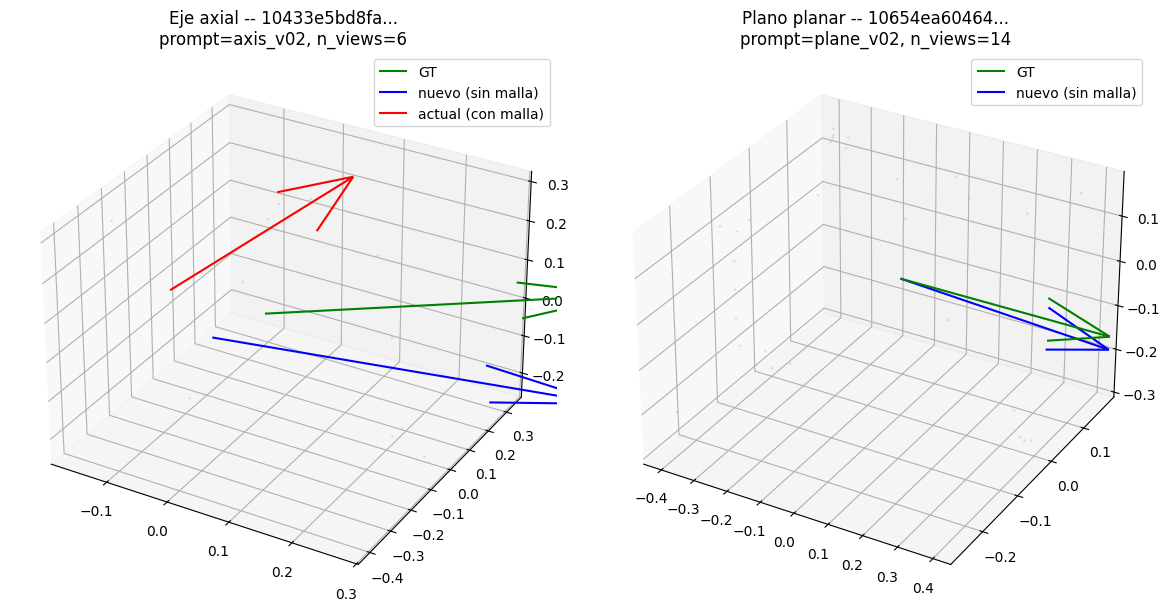

In [14]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(12, 6))

# --- Eje axial ---
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
d_new = np.array(axis_pred_new["direction"])
d_old = np.array(axis_pred_old["direction"])
d_gt = true_dir

for d, color, label, origin in [
    (d_gt, "green", "GT", true_orig),
    (d_new, "blue", "nuevo (sin malla)", axis_pred_new["origin"]),
    (d_old, "red", "actual (con malla)", axis_pred_old["origin"]),
]:
    o = np.array(origin)
    ax1.quiver(*o, *d, length=0.6, color=color, label=label, normalize=True)
ax1.scatter(*axis_mesh.vertices[::50].T, s=1, alpha=0.15, color="gray")
ax1.set_title(f"Eje axial -- {AXIS_OBJECT_ID[:12]}...\nprompt={BEST_AXIS_LABEL}, n_views={BEST_AXIS_NVIEWS}")
ax1.legend()

# --- Plano planar ---
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
if plane_ready and PLANE_BEST_FOUND:
    n_new = np.array(plane_pred_new["normal"])
    n_gt = np.array(plane_gt["elements"][best_idx]["normal"])
    for n, color, label, origin in [
        (n_gt, "green", "GT", best_true["origin"]),
        (n_new, "blue", "nuevo (sin malla)", plane_pred_new["origin"]),
    ]:
        o = np.array(origin)
        ax2.quiver(*o, *n, length=0.6, color=color, label=label, normalize=True)
    ax2.scatter(*plane_mesh.vertices[::50].T, s=1, alpha=0.15, color="gray")
    ax2.set_title(f"Plano planar -- {PLANE_OBJECT_ID[:12]}...\nprompt={BEST_PLANE_LABEL}, n_views={BEST_PLANE_NVIEWS}")
    ax2.legend()
else:
    ax2.set_title("Plano planar -- sin datos todavia")

plt.tight_layout()
plt.show()


## Conclusiones y proximos pasos

**Correccion respecto a la version anterior de esta prueba**: el objeto axial
usado originalmente (`1a9c1cbf1ca9ca24274623f5a5d0bcdc`) resulto tener un
JSON de 6 vistas generado antes del fix de `get_n_views_entries` (confirmado:
mtime 2026-05-27 vs. commit del fix `a6ffeac` el 2026-06-16). Se cambio a
`10433e5bd8fa2a337b00c7b93209c459` (`data/axis_sample/`), donde las 14
corridas de prompt disponibles usan las vistas esperadas para los 4 grupos
`VIEW_GROUPS = [1, 6, 14, 26]`, y se corrio el metodo sin malla y el metodo
con malla sobre las 14 x 4 = 56 combinaciones, con SDE_ref agregado (formula
exacta de `Mapping/reference_metrics.py::calaxisloss`).

### Resultado real del barrido prompt x n_views (eje axial)

| n_views | validas SIN malla | ang SIN malla (min/media/max) | validas CON malla | ang CON malla (min/media/max) |
|---|---|---|---|---|
| 1  | 0/14  | n/a (falla estructural: <2 vistas) | 8/14  | 82.0 / 86.2 / 88.2 |
| 6  | 13/14 | **28.1 / 43.9 / 55.9**             | 14/14 | 50.9 / 59.5 / 80.5 |
| 14 | 12/14 | 38.7 / 46.7 / 50.2                 | 14/14 | 52.0 / 72.9 / 84.2 |
| 26 | 12/14 | 38.4 / 45.4 / 50.1                 | 14/14 | 53.9 / 63.2 / 81.9 |

Mejor combinacion global (SIN malla): **`axis_v02`, n_views=6, 28.1 grados**,
SDE_ref=0.007327 -- tambien gana en SDE_ref contra el mismo combo con malla
(0.011320). Agregar mas vistas (14, 26) no mejoro el mejor caso ni el
promedio para el metodo sin malla -- hipotesis: `triangulate_line` no
pondera por confiabilidad, y a mas vistas aumenta la proporcion de vistas
donde Molmo2 repite el mismo par de coordenadas, inyectando lineas casi
duplicadas que sesgan el SVD (ver Iskakov et al. 2019, S8.3 del documento).
`n_views=1` falla estructuralmente para el metodo sin malla (14/14) y da
82-88 grados (adivinar al azar) para el metodo con malla.

### Objeto planar -- HALLAZGO PRINCIPAL: el barrido completo de prompts cambia la conclusion por completo

**Version anterior de esta prueba (incompleta)**: solo se habia probado
`plane_v01_1`, elegido a mano por ser un prompt bilateral "en teoria" bien
ajustado al algoritmo (ver nota de la seccion 2) -- daba 66-86 grados de
error segun n_views, y se interpreto como evidencia de que el metodo sin
malla para planos "no funciona bien todavia".

**Barrido real sobre las 14 x 4 = 56 combinaciones (con la iteracion de
consolidacion S4 y F1_ref/SDE_ref de `Mapping/reference_metrics.py`)**:
`plane_v01_1` resulto ser uno de los prompts que **peor** funciona (84.14
grados en n_views=6, F1_ref=0.0000 en las 3 corridas donde produjo
estimacion). Varios OTROS prompts logran resultados excelentes:

| prompt | n_views | error angular | F1_ref |
|---|---|---|---|
| `plane_v02`        | 14 | **2.65 grados** | **1.0000** |
| `plane_v00_1`      | 6  | 3.36 grados     | 0.7500 |
| `plane_v02`        | 6  | 3.36 grados     | 0.7500 |
| `plane_v02_1`      | 6  | 3.51 grados     | 0.7500 |
| `plane_v04`/`v04_1`/`v04_1_flowB` | 14 | 4.57 grados | 0.7500 |
| `plane_v05_1`      | 6  | 7.30 grados     | 0.5000 |

8 de las 34 combinaciones validas logran F1_ref > 0 -- **si hay prompts que
funcionan muy bien**, la conclusion pesimista anterior era un artefacto de
haber elegido a mano un solo prompt (justificado en teoria por S6 del
documento, pero equivocado en la practica para este objeto). Notablemente,
`plane_v04`/`plane_v04_1` -- el prompt "silhouette-midpoint" que la nota de
la seccion 2 descartaba explicitamente por la razon teorica de colapsar al
eje vertical -- funciona bien en este objeto a n_views=14 (4.57 grados,
F1_ref=0.75), contradiciendo esa expectativa teorica; conviene revisar la
salida cruda de Molmo2 para ese prompt/objeto antes de asumir que el
razonamiento de S6 esta mal en general (puede ser que este objeto en
particular no dispare el modo de falla de "colapso a x=500").

**Efecto de n_views en el barrido completo**: F1_ref maximo por n_views es
0.75 en n=6, **1.00 en n=14**, y **0.00 en n=26** (ninguna de las 13
corridas validas en n_views=26 logro F1_ref > 0, pese a que la mejor de
ellas -- `plane_v04`, 14.42 grados -- tiene un error angular razonable).
Esto es una version mucho mas concreta y matizada del hallazgo cualitativo
del paper ("mas vistas perjudican al plano"): aca no es una degradacion
pareja de todos los prompts, es que **n_views=26 sistematicamente no logra
la precision fina que hace falta para F1_ref** (umbral <=0.2 en distancia de
vector de plano), aunque el error angular puro siga siendo razonable para
algunos prompts.

**Sobre matchear el GT equivocado**: el `.txt` de `10654ea604644c8eca7ed590d69b9804`
tiene **exactamente 1 plano** de simetria -- no hay riesgo de confundir dos
GT distintos para este objeto. La iteracion de consolidacion (S4) SI
encontro un segundo plano candidato en 19 de las 34 combinaciones validas
(inevitable dado que solo hay 1 plano real, ese segundo candidato es por
construccion espurio), pero **para los mejores combos de la tabla de arriba,
el "plano 0" (el candidato inicial, sin necesidad de iterar) ya es
practicamente perfecto** -- el hallazgo de la version anterior (que en
n_views=26 el plano residual superaba al plano inicial) sigue siendo real
para `plane_v01_1` especificamente, pero no es el cuadro general: para los
prompts que SI funcionan bien, no hace falta la iteracion para acertar.

**Metricas de referencia**: F1_ref (formula exacta de `f1_match_counts`,
sin reimplementar) confirma independientemente el ranking de error angular
-- los prompts con mejor angulo son tambien los que logran F1_ref > 0, lo
cual es una buena senal de consistencia entre ambas metricas (no siempre es
asi, ver `docs/metricas_evaluacion.md` sobre por que SDE/F1_ref y error
angular pueden discrepar).

**Proximos pasos**:
1. Investigar por que `plane_v02`, `plane_v00_1`, `plane_v02_1` y
   `plane_v04*` funcionan tan bien en este objeto -- revisar sus prompts
   exactos (`prompts_registry.py`) y su salida cruda de Molmo2 para entender
   que los distingue de `plane_v01_1`/`plane_v03*`/`plane_v05` (que fallan
   con 70-90 grados). Es plausible que el patron de "bilateral real" que
   motivo elegir v01_1 a mano no sea el factor decisivo -- revisar antes de
   generalizar la regla de seleccion de prompts a otros objetos.
2. Correr este mismo barrido completo (14 prompts x 4 n_views, consolidacion
   S4, F1_ref/SDE_ref) sobre **mas objetos planares** para saber si
   `plane_v02`/`plane_v00_1`/`plane_v04*` ganan consistentemente o si el
   ranking de prompts es especifico de este objeto -- con un solo objeto no
   se puede distinguir "mejor prompt en general" de "este objeto en
   particular le vino bien a este prompt".
3. Correr la consolidacion sobre un objeto con GT de 2-3 planos reales (el
   dataset curado tiene 152 objetos con 2 planos y 6 con 3, ver
   `docs/pipeline_sin_malla.md` S4) para validar el criterio de parada en el
   caso para el que fue disenado.
4. Investigar por que el metodo CON malla actual (ray-cast + SVD) sale peor
   que el sin malla en el objeto axial, para los 3 n_views comparables.
5. Antes de escalar: correr esto sobre **varios** objetos de cada tipo (no
   solo uno) para tener una validacion estadistica real -- ver
   `docs/pipeline_sin_malla.md` seccion 7. Si hay JSONs de pointing
   generados en el servidor antes del 2026-06-16 (fecha del fix de
   `get_n_views_entries`), regenerarlos antes de incluirlos -- el mismo
   chequeo de indices de la seccion de diagnostico sirve para auditarlos.